In [1]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', context='paper', font_scale=1.1)
plt.rcParams['figure.dpi'] = 150

DOWNLOADS = Path(r"C:\Users\USER\Downloads")

In [2]:
# ── File registry ──────────────────────────────────────────────────────────────
# Each entry: (file_path, model_name, judge_name, condition, judge_type)
# judge_type = 'accuracy' or 'reasoning'

FILE_REGISTRY = [
    # ── GLM 5.1 accuracy ──
    (DOWNLOADS / "llama8b_glmjudge_0shot.csv",          "Llama-8B-DSK", "GLM-5.1", "0-shot",       "accuracy"),
    (DOWNLOADS / "llama8b_glmjudge_1shot.csv",          "Llama-8B-DSK", "GLM-5.1", "1-shot",       "accuracy"),
    (DOWNLOADS / "medgemma_glmjudge_0shot.csv",         "MedGemma",     "GLM-5.1", "0-shot",       "accuracy"),
    (DOWNLOADS / "medgemma_glmjudge_1shot.csv",         "MedGemma",     "GLM-5.1", "1-shot",       "accuracy"),
    (DOWNLOADS / "qwen_glmjudge_0shot.csv",             "Qwen-3.6",     "GLM-5.1", "0-shot",       "accuracy"),
    (DOWNLOADS / "qwen_glmjudge_1shot.csv",             "Qwen-3.6",     "GLM-5.1", "1-shot",       "accuracy"),

    # ── DeepSeek accuracy ──
    (DOWNLOADS / "llama8b_judge_0shot.csv",             "Llama-8B-DSK", "DeepSeek","0-shot",       "accuracy"),
    (DOWNLOADS / "llama8b_judge_1shot.csv",             "Llama-8B-DSK", "DeepSeek","1-shot",       "accuracy"),
    (DOWNLOADS / "medgemma_judgedsk_0shot.csv",         "MedGemma",     "DeepSeek","0-shot",       "accuracy"),
    (DOWNLOADS / "medgemma_judgedsk_1shot.csv",         "MedGemma",     "DeepSeek","1-shot",       "accuracy"),
    (DOWNLOADS / "qwen3_6_judge_0shot.csv",             "Qwen-3.6",     "DeepSeek","0-shot",       "accuracy"),
    (DOWNLOADS / "qwen3_6_judge_1shot.csv",             "Qwen-3.6",     "DeepSeek","1-shot",       "accuracy"),

    # ── GLM 5.1 reasoning ──
    (DOWNLOADS / "llama8b_glmjudge_negated.csv",        "Llama-8B-DSK", "GLM-5.1", "negated",      "reasoning"),
    (DOWNLOADS / "llama8b_glmjudge_random_masked.csv",  "Llama-8B-DSK", "GLM-5.1", "random_masked","reasoning"),
    (DOWNLOADS / "llama8b_glmjudge_counterfactual.csv", "Llama-8B-DSK", "GLM-5.1", "counterfactual","reasoning"),
    (DOWNLOADS / "medgemma_glmjudge_negated.csv",       "MedGemma",     "GLM-5.1", "negated",      "reasoning"),
    (DOWNLOADS / "medgemma_glmjudge_random_masked.csv", "MedGemma",     "GLM-5.1", "random_masked","reasoning"),
    (DOWNLOADS / "medgemma_glmjudge_counterfactual.csv","MedGemma",     "GLM-5.1", "counterfactual","reasoning"),
    (DOWNLOADS / "qwen36_glmjudge_negated.csv",         "Qwen-3.6",     "GLM-5.1", "negated",      "reasoning"),
    (DOWNLOADS / "qwen36_glmjudge_random_masked.csv",  "Qwen-3.6",     "GLM-5.1", "random_masked","reasoning"),
    (DOWNLOADS / "qwen36_glmjudge_counterfactual.csv", "Qwen-3.6",     "GLM-5.1", "counterfactual","reasoning"),

    # ── DeepSeek reasoning ──
    (DOWNLOADS / "llama8b_judge_negated.csv",           "Llama-8B-DSK", "DeepSeek","negated",      "reasoning"),
    (DOWNLOADS / "llama8b_judge_random_masked.csv",     "Llama-8B-DSK", "DeepSeek","random_masked","reasoning"),
    (DOWNLOADS / "llama8b_judge_counterfactual.csv",    "Llama-8B-DSK", "DeepSeek","counterfactual","reasoning"),
    (DOWNLOADS / "medgemma_judge_negated.csv",          "MedGemma",     "DeepSeek","negated",      "reasoning"),
    (DOWNLOADS / "medgemma_judge_random_masked.csv",    "MedGemma",     "DeepSeek","random_masked","reasoning"),
    (DOWNLOADS / "medgemma_judge_counterfactual.csv",   "MedGemma",     "DeepSeek","counterfactual","reasoning"),
]

def load_registry(registry):
    """Load all available CSVs from registry, return concatenated DataFrame."""
    frames = []
    for path, model, judge, condition, jtype in registry:
        if not path.exists():
            continue
        df = pd.read_csv(path)
        df['model'] = model
        df['judge'] = judge
        df['condition'] = condition
        df['judge_type'] = jtype
        frames.append(df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

df_all = load_registry(FILE_REGISTRY)
print(f"Loaded {len(df_all)} rows from {df_all['judge'].nunique()} judge(s) across {df_all['model'].nunique()} model(s)")

Loaded 250 rows from 2 judge(s) across 3 model(s)


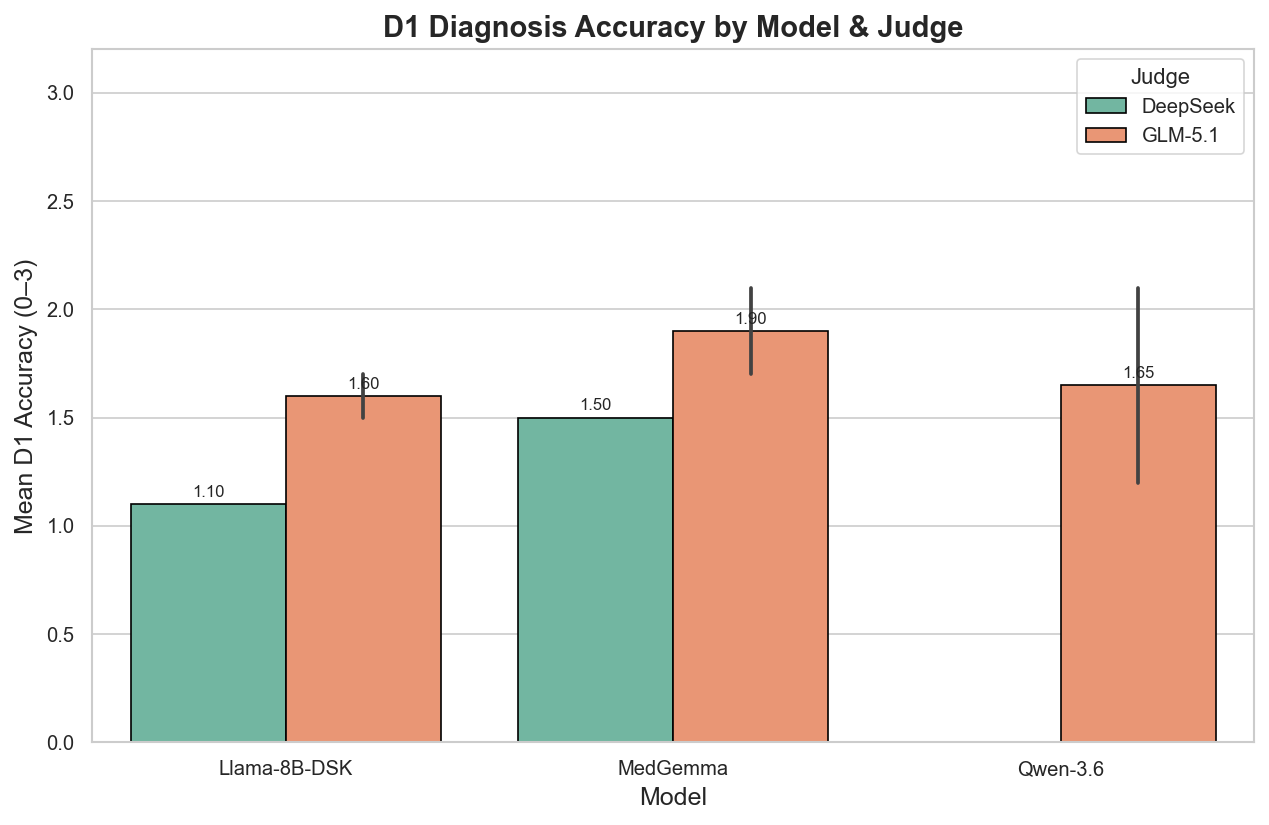

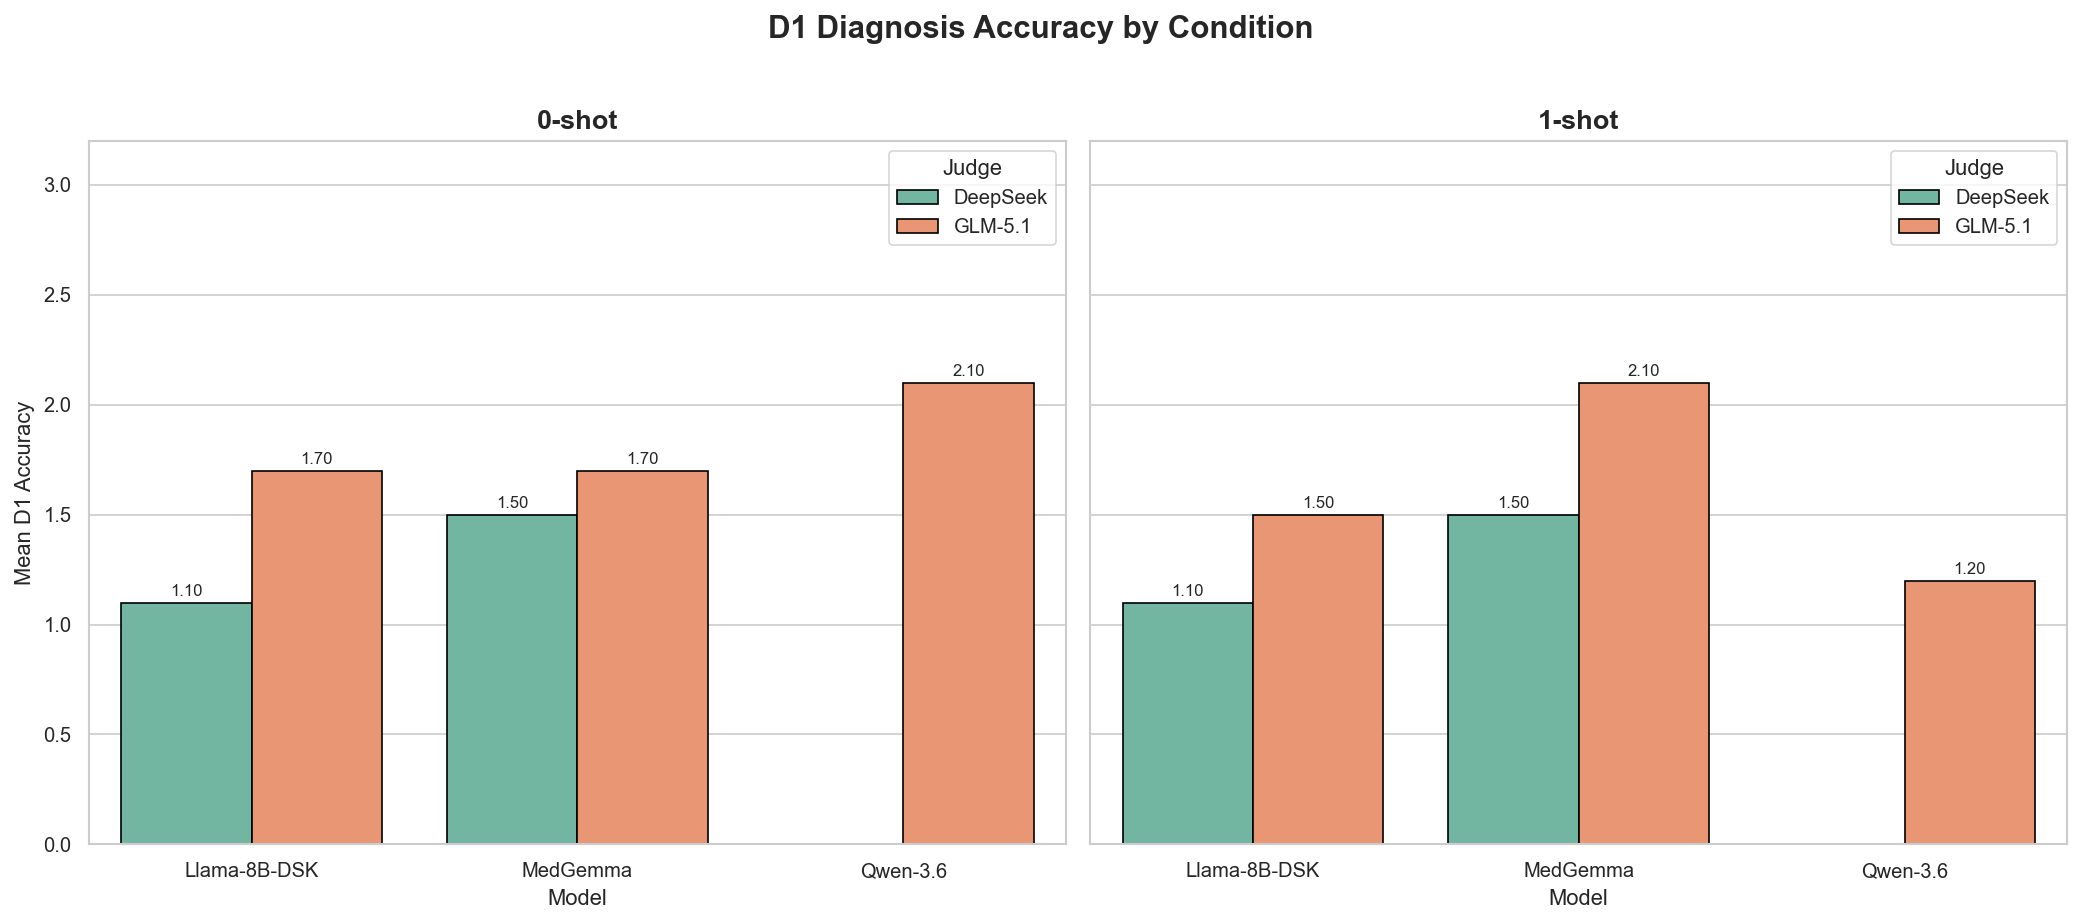

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# Chart 1: Accuracy Comparison (Grouped Bar Chart)
# ═══════════════════════════════════════════════════════════════════════════════

df_acc = df_all[df_all['judge_type'] == 'accuracy'].copy()
if not df_acc.empty and 'd1_accuracy' in df_acc.columns:
    # Filter valid scores only
    df_acc = df_acc[df_acc['d1_accuracy'].between(0, 3)]

    summary = (
        df_acc.groupby(['model', 'condition', 'judge'])['d1_accuracy']
        .mean()
        .reset_index()
        .rename(columns={'d1_accuracy': 'mean_d1'})
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    g = sns.barplot(
        data=summary,
        x='model', y='mean_d1', hue='judge',
        palette='Set2', edgecolor='black',
        order=['Llama-8B-DSK', 'MedGemma', 'Qwen-3.6'],
        ax=ax
    )
    ax.set_title('D1 Diagnosis Accuracy by Model & Judge', fontsize=14, fontweight='bold')
    ax.set_ylabel('Mean D1 Accuracy (0–3)', fontsize=12)
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylim(0, 3.2)
    ax.legend(title='Judge', loc='upper right')

    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=2, fontsize=8)

    # Facet by condition (0-shot / 1-shot)
    fig2, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    for ax2, cond in zip(axes, ['0-shot', '1-shot']):
        sub = summary[summary['condition'] == cond]
        if sub.empty:
            ax2.set_visible(False)
            continue
        sns.barplot(
            data=sub, x='model', y='mean_d1', hue='judge',
            palette='Set2', edgecolor='black',
            order=['Llama-8B-DSK', 'MedGemma', 'Qwen-3.6'],
            ax=ax2
        )
        ax2.set_title(f'{cond}', fontsize=13, fontweight='bold')
        ax2.set_ylabel('Mean D1 Accuracy' if cond == '0-shot' else '')
        ax2.set_xlabel('Model')
        ax2.set_ylim(0, 3.2)
        ax2.legend(title='Judge', loc='upper right')
        for container in ax2.containers:
            ax2.bar_label(container, fmt='%.2f', padding=2, fontsize=8)
    fig2.suptitle('D1 Diagnosis Accuracy by Condition', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No accuracy data available yet. Run the judge notebooks first.")

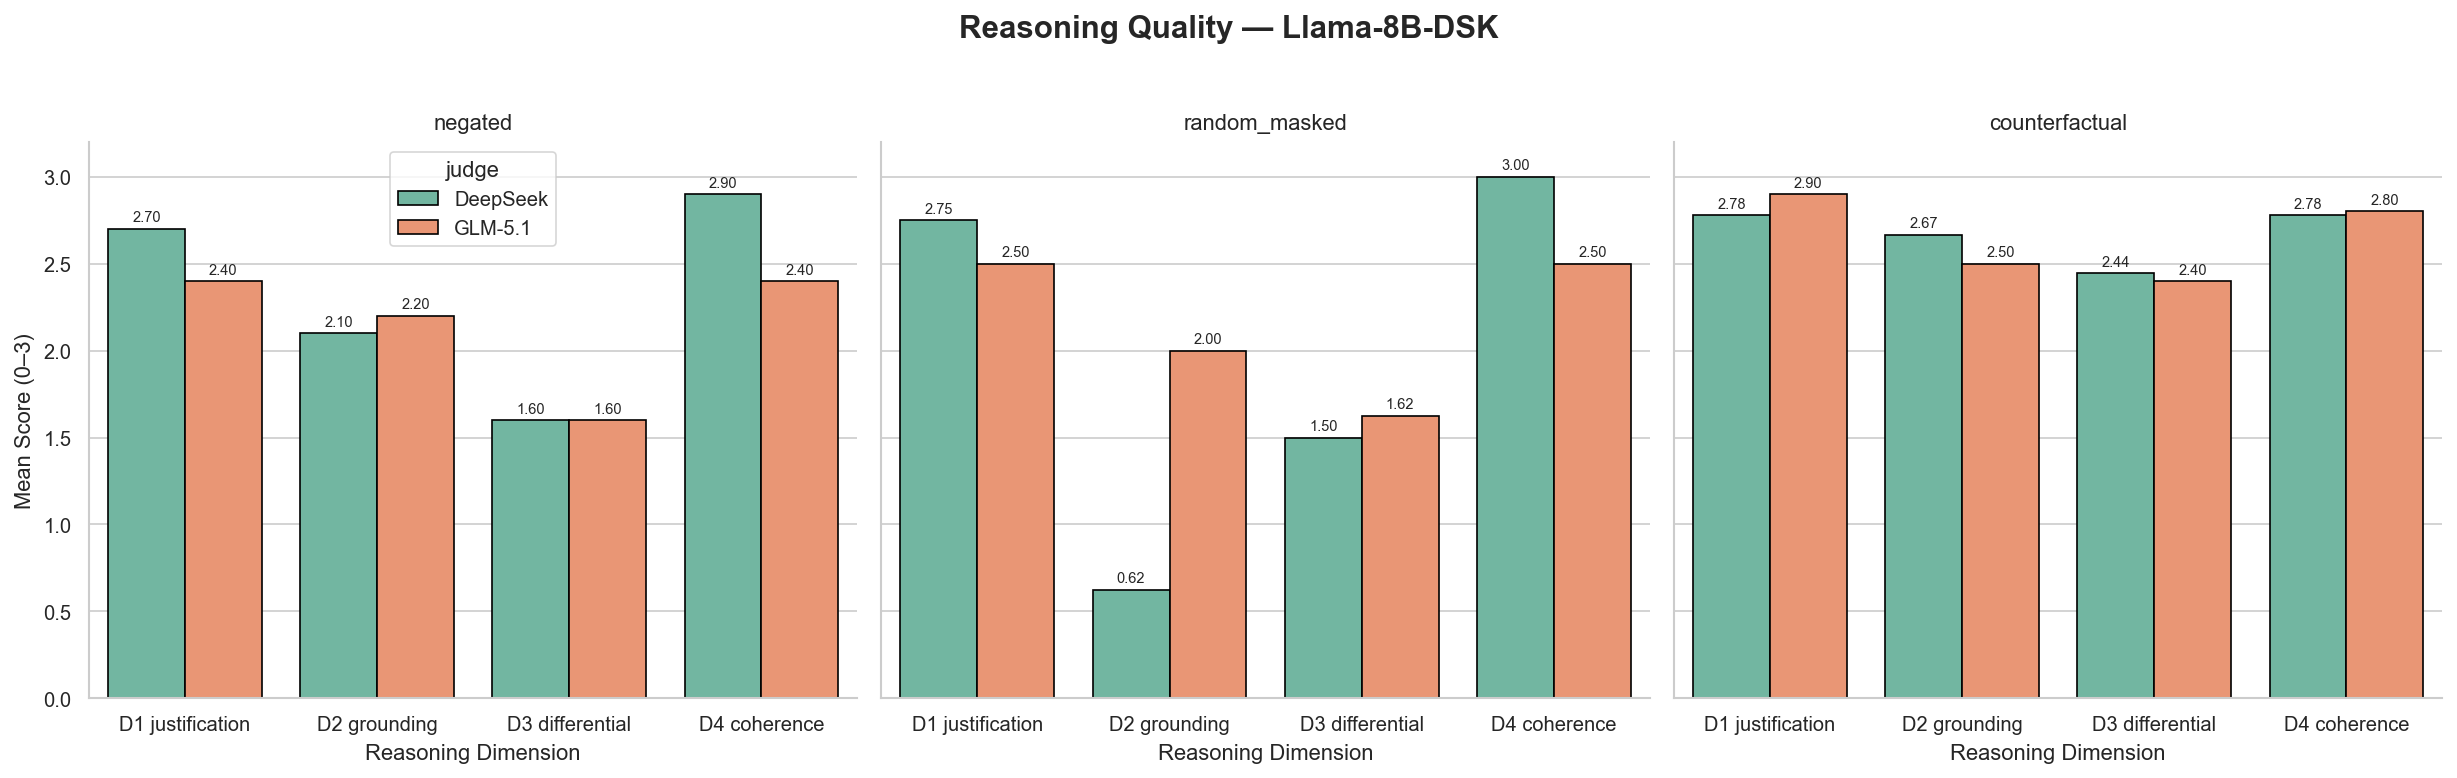

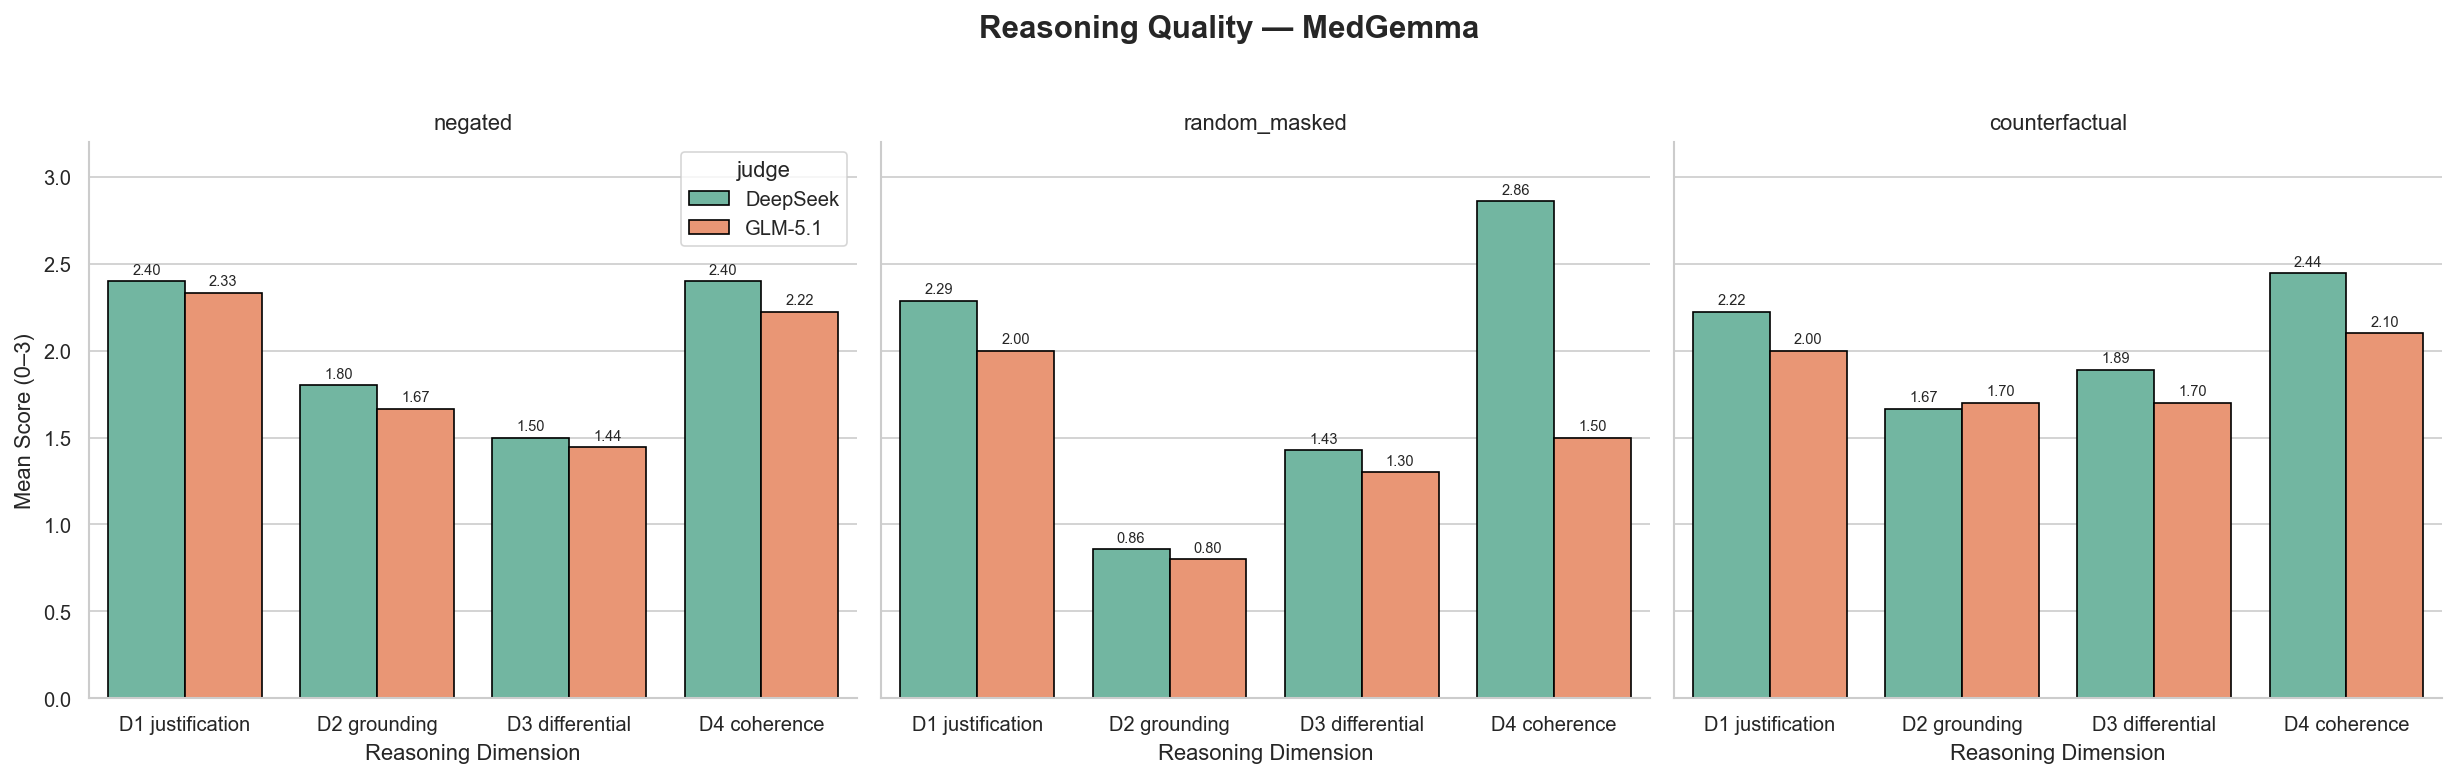

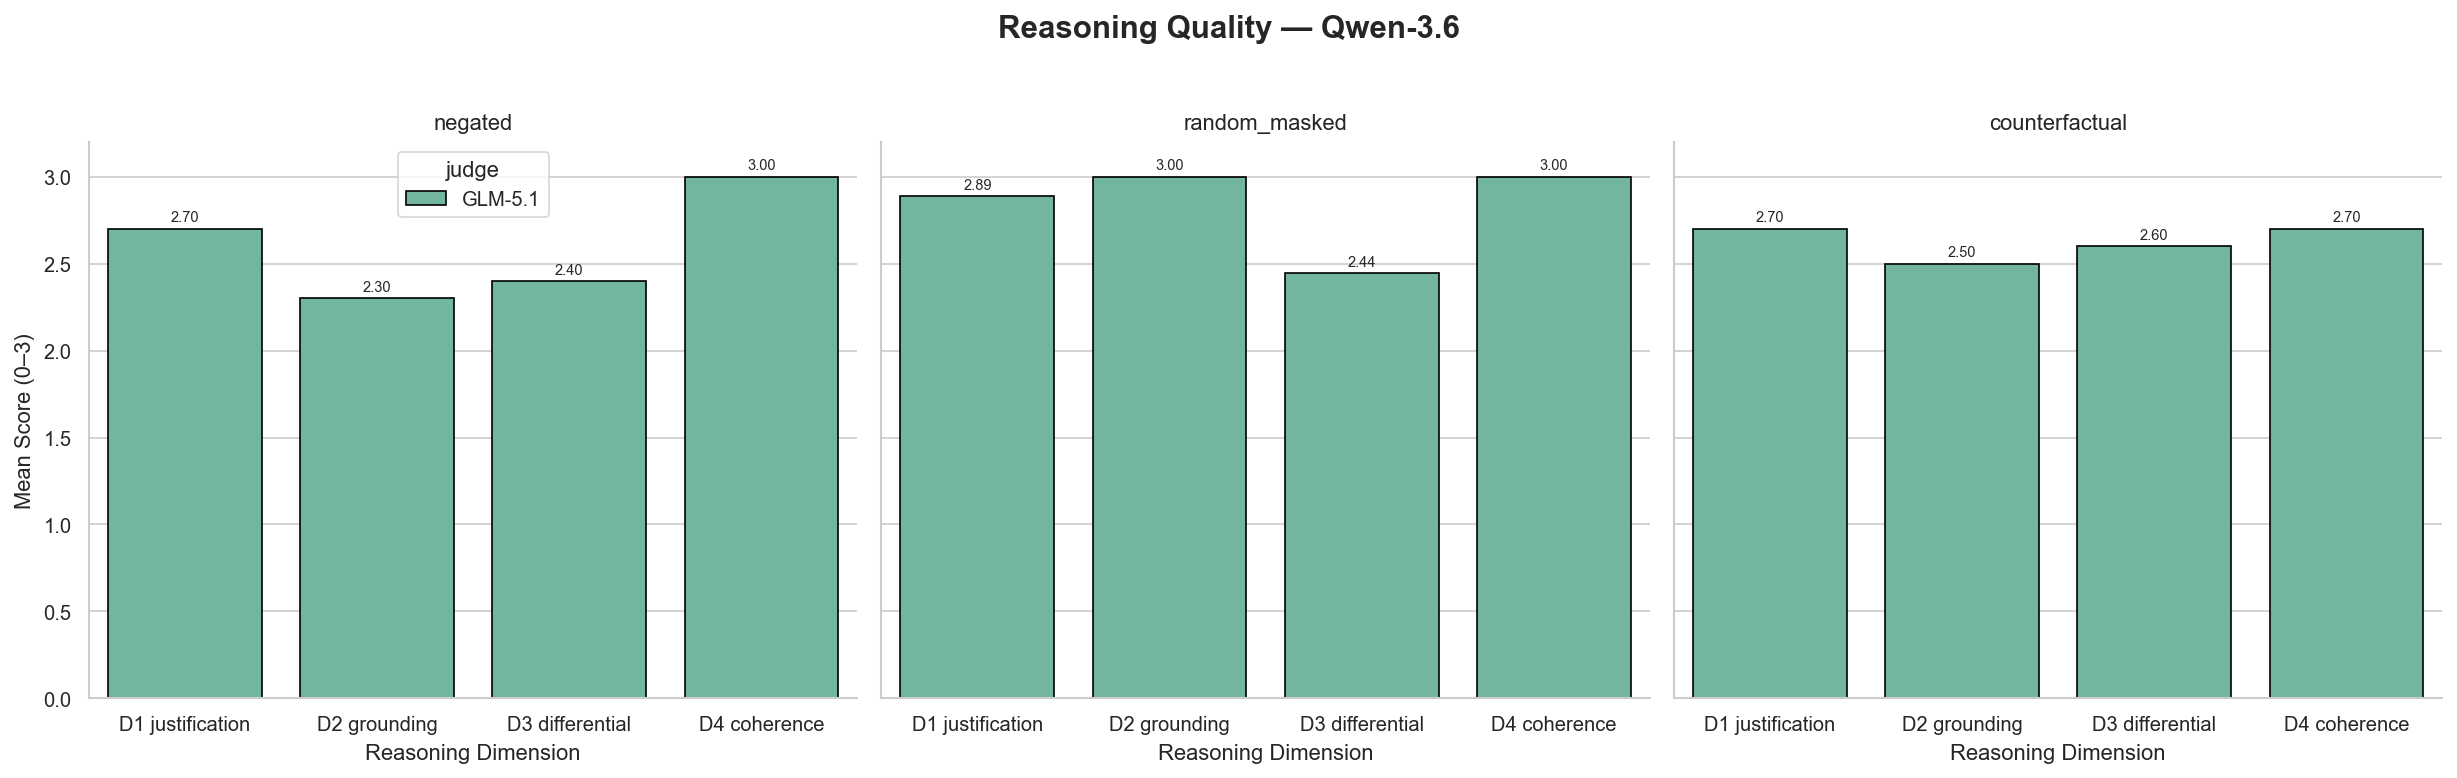

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# Chart 2: Reasoning Quality (D1–D4 Grouped Bar Chart)
# ═══════════════════════════════════════════════════════════════════════════════

df_reason = df_all[df_all['judge_type'] == 'reasoning'].copy()
reason_cols = ['d1_justification', 'd2_grounding', 'd3_differential', 'd4_coherence']

if not df_reason.empty and all(c in df_reason.columns for c in reason_cols):
    # Filter valid scores
    for c in reason_cols:
        df_reason = df_reason[df_reason[c].between(0, 3)]

    # Melt for seaborn
    df_melt = df_reason.melt(
        id_vars=['model', 'condition', 'judge'],
        value_vars=reason_cols,
        var_name='dimension', value_name='score'
    )
    df_melt['dimension'] = df_melt['dimension'].str.replace('d1_', 'D1 ').str.replace('d2_', 'D2 ').str.replace('d3_', 'D3 ').str.replace('d4_', 'D4 ')

    summary_r = (
        df_melt.groupby(['model', 'condition', 'judge', 'dimension'])['score']
        .mean()
        .reset_index()
    )

    # One figure per model, facet by condition
    models = summary_r['model'].unique()
    for mdl in models:
        sub = summary_r[summary_r['model'] == mdl]
        if sub.empty:
            continue
        g = sns.catplot(
            data=sub, x='dimension', y='score', hue='judge', col='condition',
            kind='bar', palette='Set2', edgecolor='black',
            col_order=['negated', 'random_masked', 'counterfactual'],
            height=5, aspect=1.1, legend_out=False
        )
        g.set_axis_labels("Reasoning Dimension", "Mean Score (0–3)")
        g.set_titles("{col_name}")
        g.fig.suptitle(f'Reasoning Quality — {mdl}', fontsize=15, fontweight='bold', y=1.03)
        for ax in g.axes.flat:
            ax.set_ylim(0, 3.2)
            for container in ax.containers:
                ax.bar_label(container, fmt='%.2f', padding=2, fontsize=7)
        plt.tight_layout()
        plt.show()
else:
    print("No reasoning data available yet. Run the judge notebooks first.")

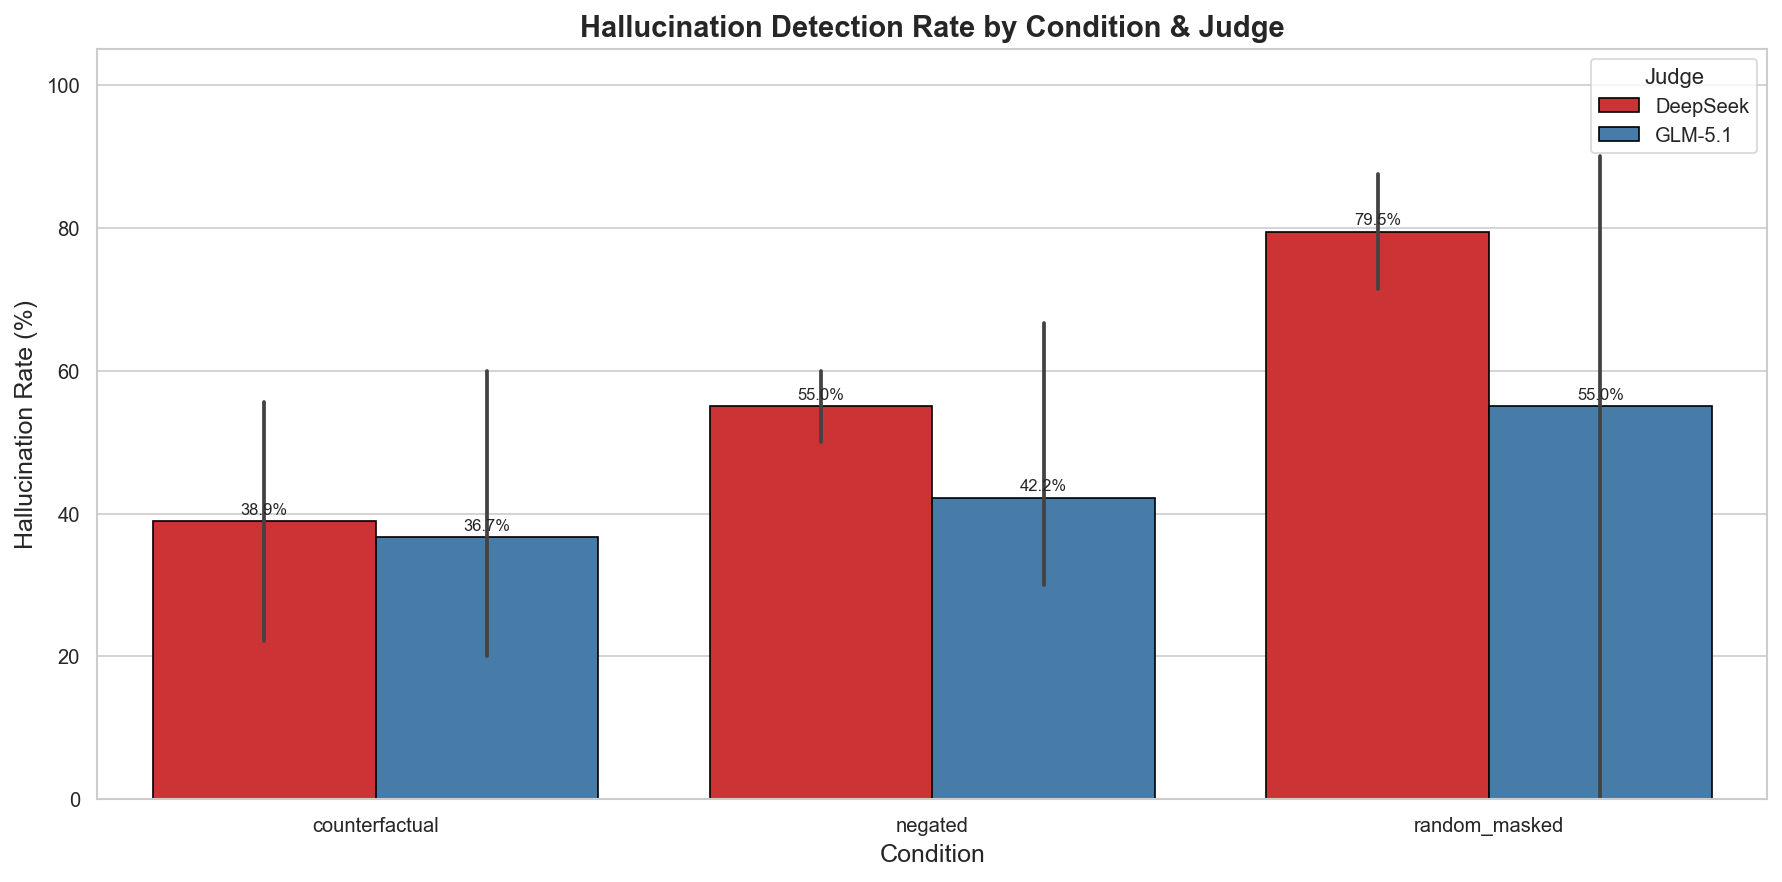

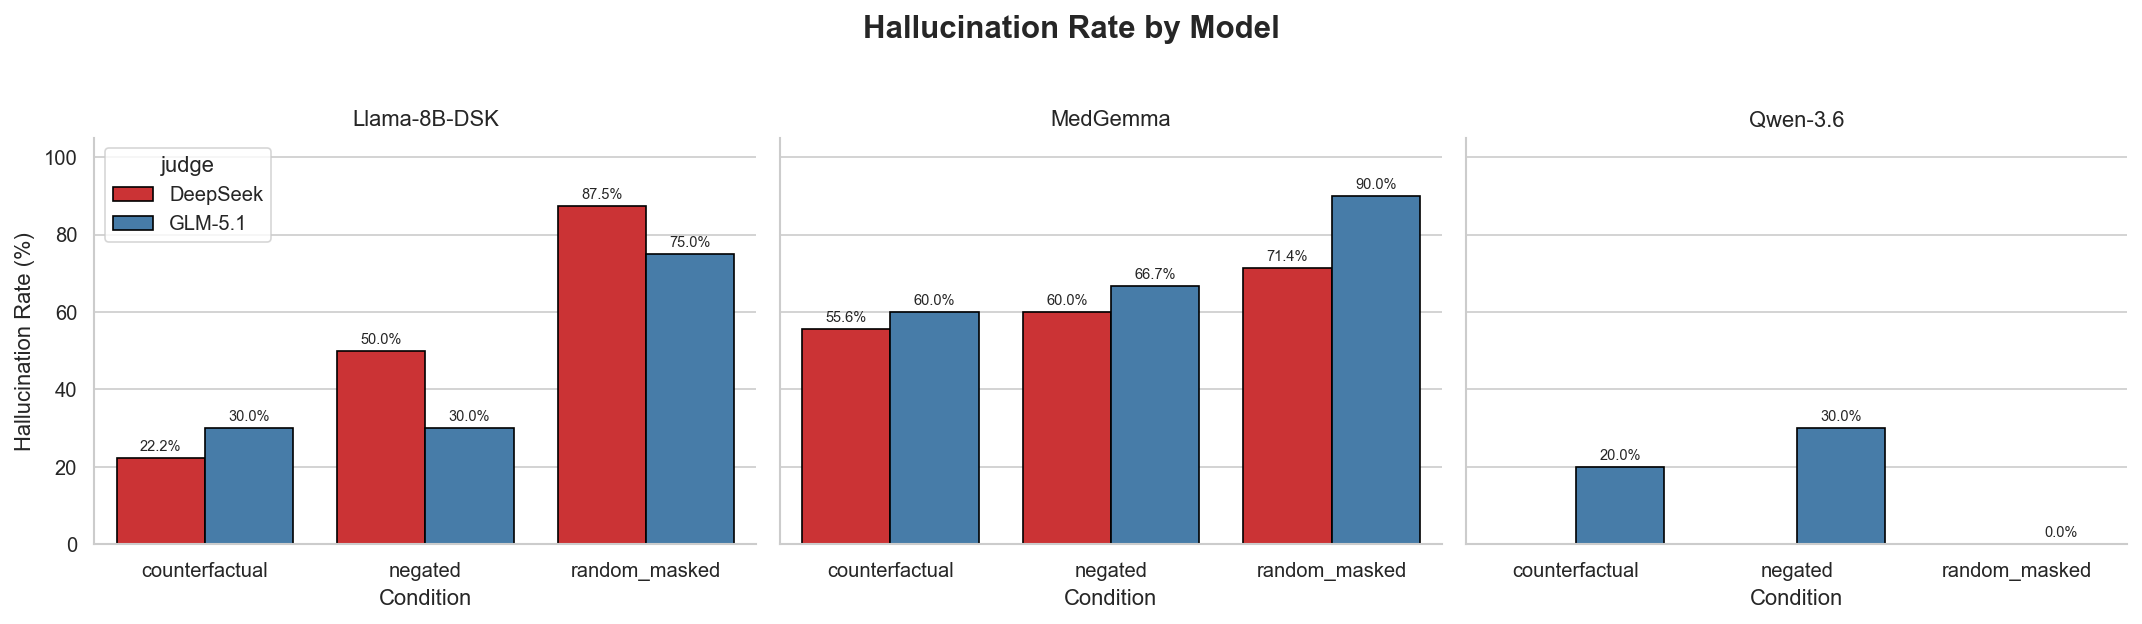

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# Chart 3: Hallucination Rate
# ═══════════════════════════════════════════════════════════════════════════════

if not df_reason.empty and 'hallucination_detected' in df_reason.columns:
    hall = (
        df_reason.groupby(['model', 'condition', 'judge'])['hallucination_detected']
        .apply(lambda x: x.astype(bool).mean() * 100)
        .reset_index()
        .rename(columns={'hallucination_detected': 'hallucination_pct'})
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(
        data=hall, x='condition', y='hallucination_pct', hue='judge',
        palette='Set1', edgecolor='black', ax=ax
    )
    ax.set_title('Hallucination Detection Rate by Condition & Judge', fontsize=14, fontweight='bold')
    ax.set_ylabel('Hallucination Rate (%)', fontsize=12)
    ax.set_xlabel('Condition', fontsize=12)
    ax.set_ylim(0, 105)
    ax.legend(title='Judge', loc='upper right')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=8)
    plt.tight_layout()
    plt.show()

    # Per-model facet
    g = sns.catplot(
        data=hall, x='condition', y='hallucination_pct', hue='judge', col='model',
        kind='bar', palette='Set1', edgecolor='black',
        col_wrap=3, height=4, aspect=1.2, legend_out=False
    )
    g.set_axis_labels("Condition", "Hallucination Rate (%)")
    g.set_titles("{col_name}")
    g.fig.suptitle('Hallucination Rate by Model', fontsize=15, fontweight='bold', y=1.03)
    for ax in g.axes.flat:
        ax.set_ylim(0, 105)
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=7)
    plt.tight_layout()
    plt.show()
else:
    print("No hallucination data available yet.")

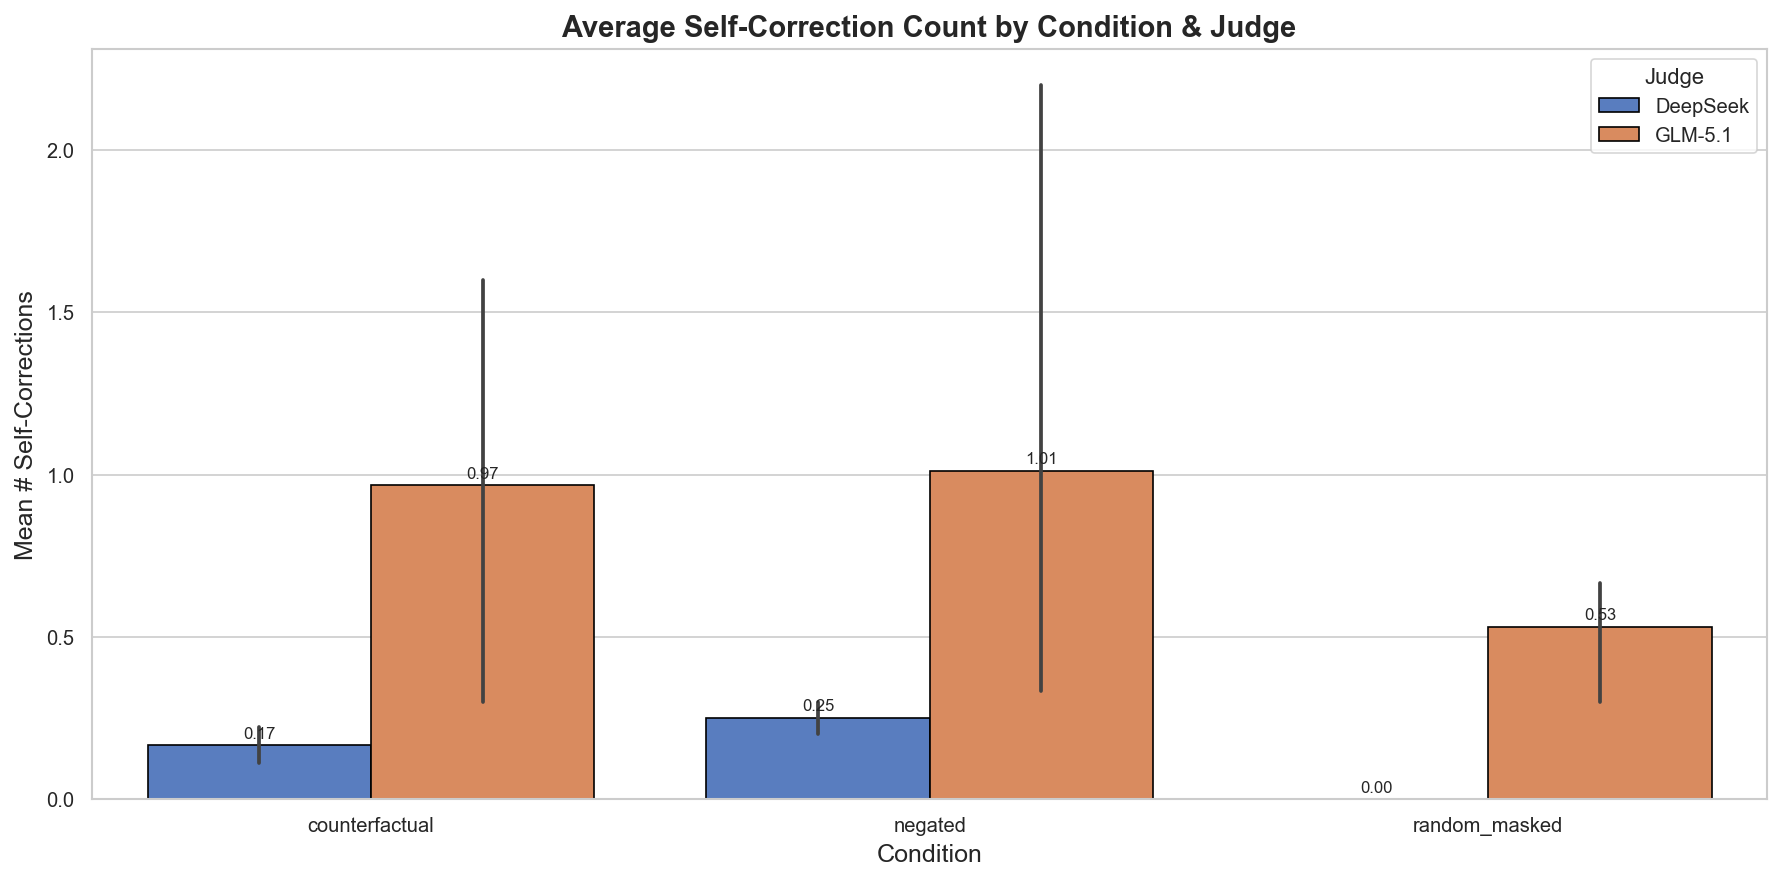

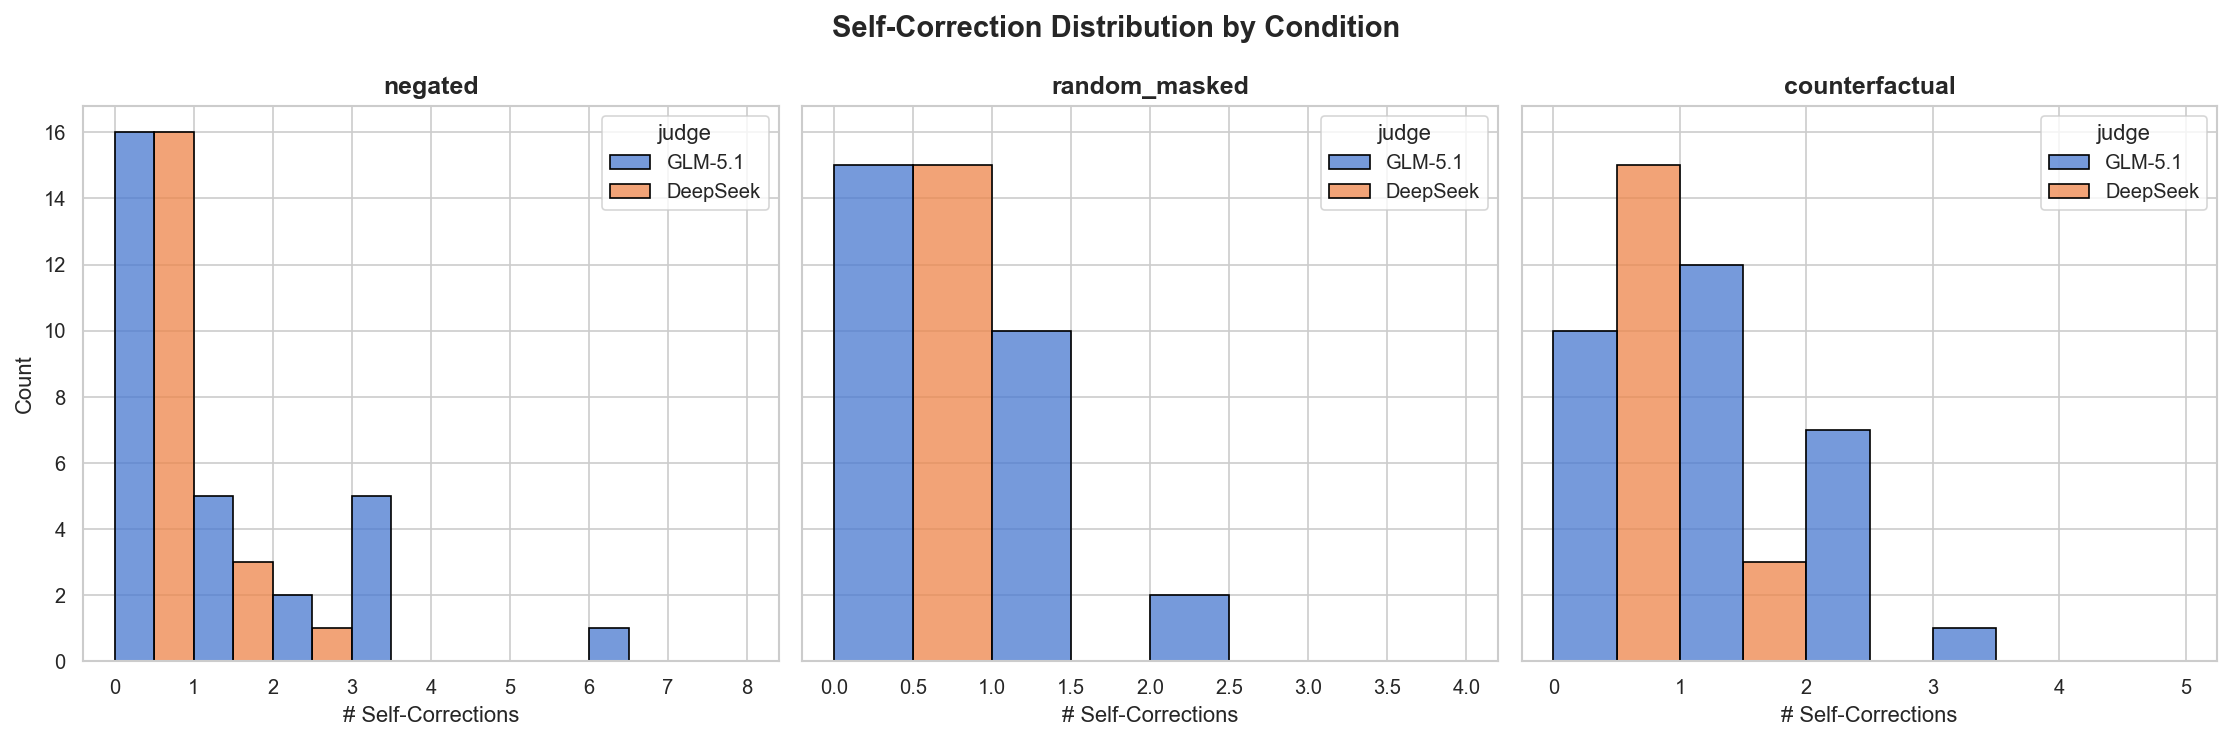

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# Chart 4: Self-Correction Frequency
# ═══════════════════════════════════════════════════════════════════════════════

if not df_reason.empty and 'num_self_correcting' in df_reason.columns:
    # Filter valid counts (>=0)
    df_sc = df_reason[df_reason['num_self_correcting'] >= 0].copy()

    sc = (
        df_sc.groupby(['model', 'condition', 'judge'])['num_self_correcting']
        .mean()
        .reset_index()
        .rename(columns={'num_self_correcting': 'mean_self_corr'})
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(
        data=sc, x='condition', y='mean_self_corr', hue='judge',
        palette='muted', edgecolor='black', ax=ax
    )
    ax.set_title('Average Self-Correction Count by Condition & Judge', fontsize=14, fontweight='bold')
    ax.set_ylabel('Mean # Self-Corrections', fontsize=12)
    ax.set_xlabel('Condition', fontsize=12)
    ax.legend(title='Judge', loc='upper right')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=2, fontsize=8)
    plt.tight_layout()
    plt.show()

    # Distribution histogram
    fig2, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    for ax2, cond in zip(axes, ['negated', 'random_masked', 'counterfactual']):
        sub = df_sc[df_sc['condition'] == cond]
        if sub.empty:
            ax2.set_visible(False)
            continue
        sns.histplot(
            data=sub, x='num_self_correcting', hue='judge',
            multiple='dodge', bins=range(0, int(sub['num_self_correcting'].max()) + 3),
            palette='muted', edgecolor='black', ax=ax2
        )
        ax2.set_title(f'{cond}', fontsize=12, fontweight='bold')
        ax2.set_xlabel('# Self-Corrections')
        ax2.set_ylabel('Count' if cond == 'negated' else '')
    fig2.suptitle('Self-Correction Distribution by Condition', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No self-correction data available yet.")

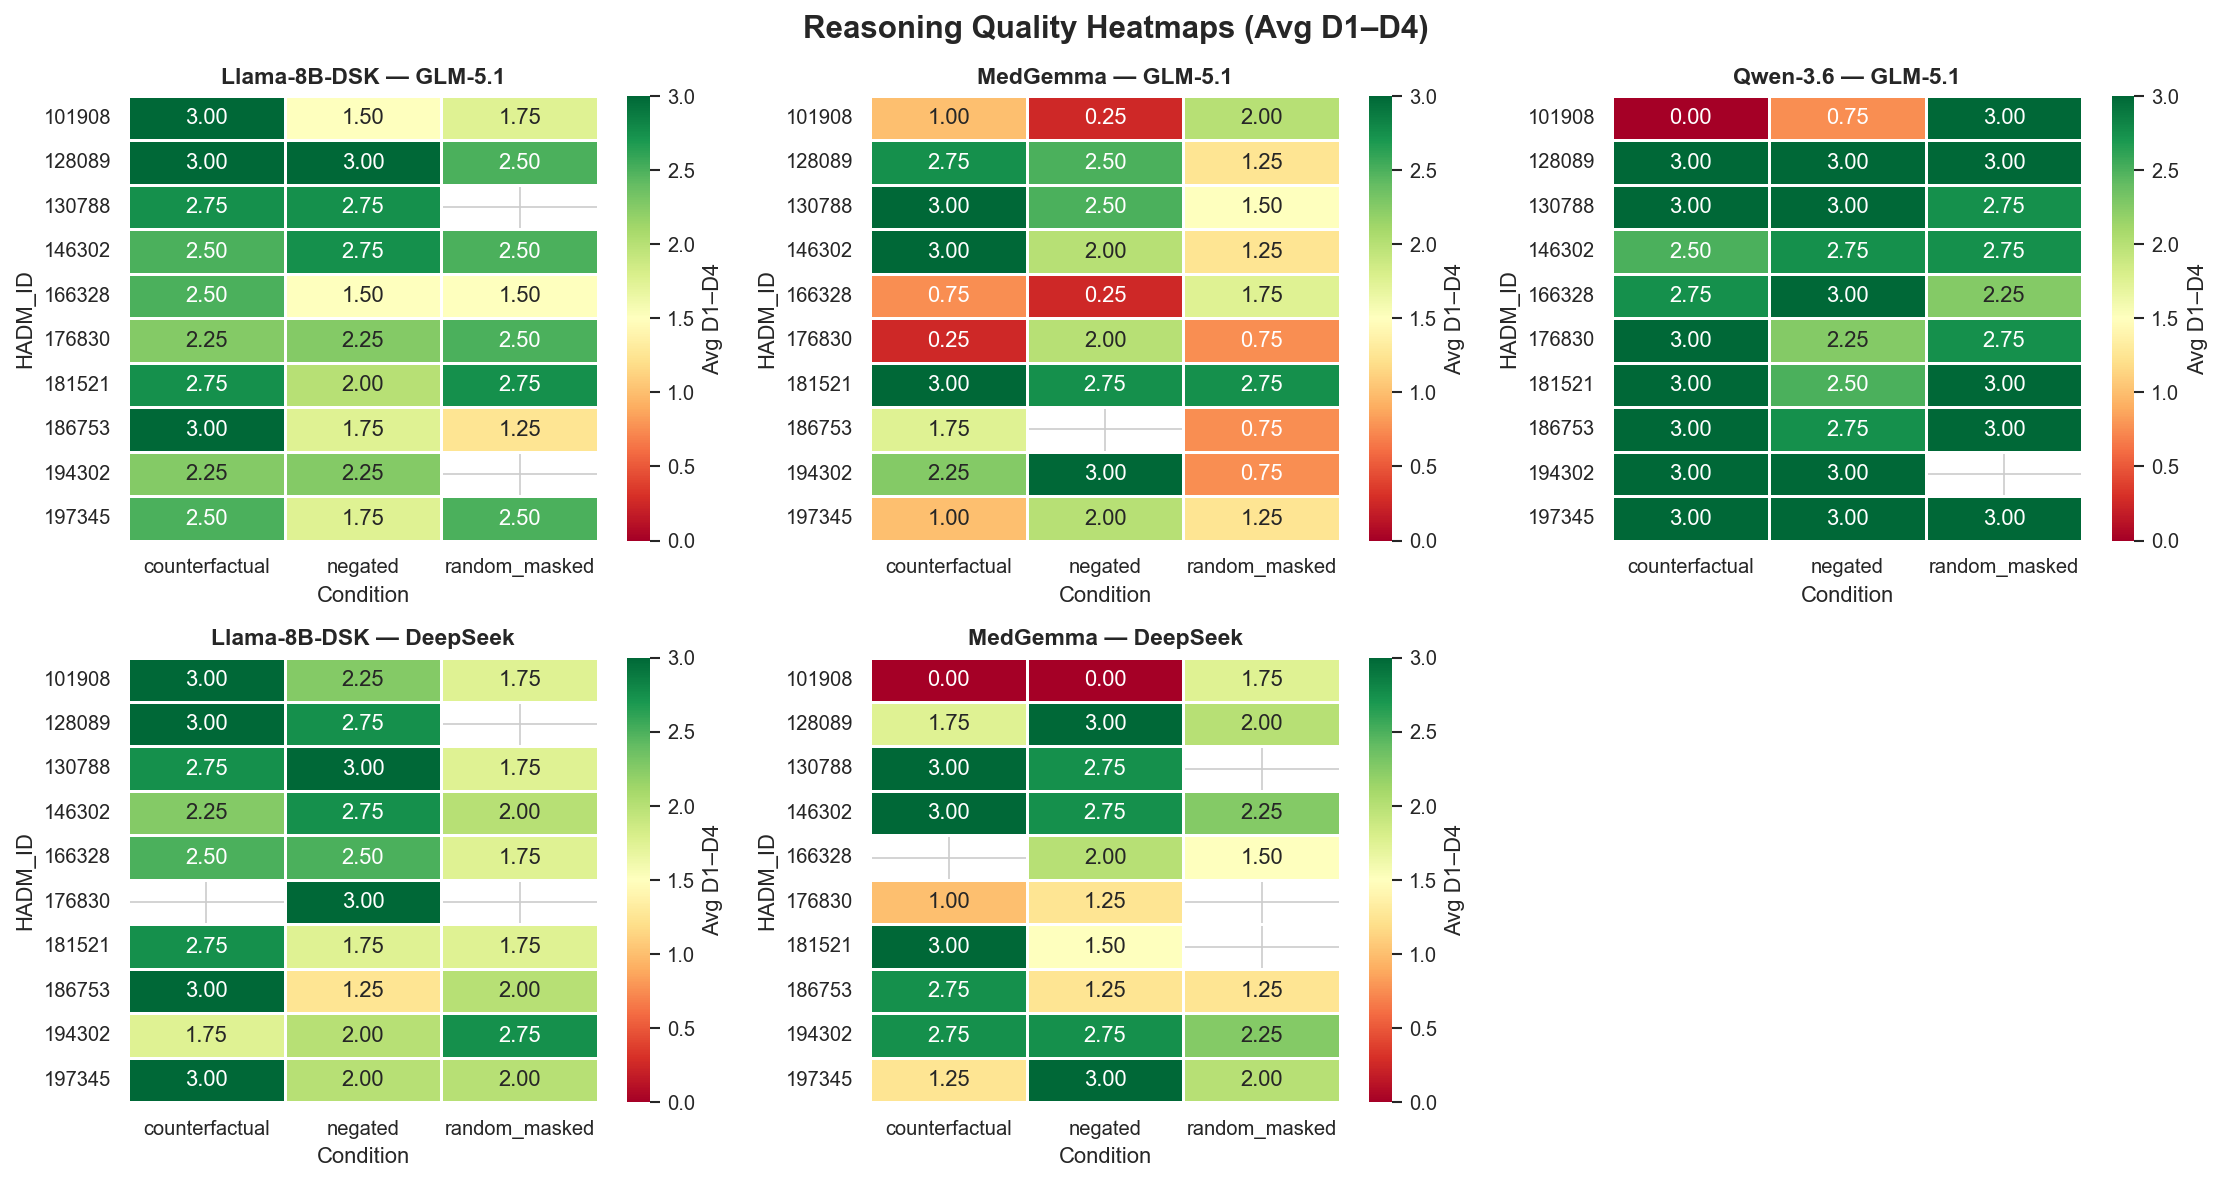

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# Chart 5: Heatmaps — Score Distribution by HADM_ID × Condition
# ═══════════════════════════════════════════════════════════════════════════════

def plot_reasoning_heatmap(df_sub, model_name, judge_name, ax):
    """Plot a heatmap of D1–D4 scores per HADM for a given model+judge."""
    cols = ['HADM_ID', 'condition', 'd1_justification', 'd2_grounding', 'd3_differential', 'd4_coherence']
    if not all(c in df_sub.columns for c in cols):
        return
    df_h = df_sub[cols].copy()
    for c in cols[2:]:
        df_h[c] = pd.to_numeric(df_h[c], errors='coerce')
    df_h = df_h.groupby(['HADM_ID', 'condition']).mean().reset_index()
    df_h['avg_d'] = df_h[cols[2:]].mean(axis=1)
    pivot = df_h.pivot(index='HADM_ID', columns='condition', values='avg_d')
    if pivot.empty:
        return
    sns.heatmap(
        pivot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=3,
        linewidths=.5, ax=ax, cbar_kws={'label': 'Avg D1–D4'}
    )
    ax.set_title(f'{model_name} — {judge_name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Condition')
    ax.set_ylabel('HADM_ID')

if not df_reason.empty:
    combos = df_reason[['model', 'judge']].drop_duplicates().values
    n = len(combos)
    cols = min(3, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    if n == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    for ax, (mdl, jdg) in zip(axes, combos):
        sub = df_reason[(df_reason['model'] == mdl) & (df_reason['judge'] == jdg)]
        plot_reasoning_heatmap(sub, mdl, jdg, ax)
    for ax in axes[n:]:
        ax.set_visible(False)
    fig.suptitle('Reasoning Quality Heatmaps (Avg D1–D4)', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No reasoning data for heatmaps.")

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# Chart 6: Export Summary Table to CSV
# ═══════════════════════════════════════════════════════════════════════════════

summary_records = []

# Accuracy summary
if not df_acc.empty:
    for (model, condition, judge), grp in df_acc.groupby(['model', 'condition', 'judge']):
        summary_records.append({
            'model': model, 'condition': condition, 'judge': judge,
            'judge_type': 'accuracy', 'n': len(grp),
            'd1_accuracy_mean': grp['d1_accuracy'].mean(),
            'd1_accuracy_std': grp['d1_accuracy'].std(),
        })

# Reasoning summary
if not df_reason.empty:
    for (model, condition, judge), grp in df_reason.groupby(['model', 'condition', 'judge']):
        rec = {
            'model': model, 'condition': condition, 'judge': judge,
            'judge_type': 'reasoning', 'n': len(grp),
        }
        for c in reason_cols:
            if c in grp.columns:
                rec[f'{c}_mean'] = grp[c].mean()
                rec[f'{c}_std'] = grp[c].std()
        if 'hallucination_detected' in grp.columns:
            rec['hallucination_rate_pct'] = grp['hallucination_detected'].astype(bool).mean() * 100
        if 'num_self_correcting' in grp.columns:
            valid_sc = grp[grp['num_self_correcting'] >= 0]['num_self_correcting']
            rec['self_corr_mean'] = valid_sc.mean() if len(valid_sc) > 0 else np.nan
        summary_records.append(rec)

summary_df = pd.DataFrame(summary_records)
out_path = DOWNLOADS / "judge_summary_table.csv"
summary_df.to_csv(out_path, index=False)
print(f"Summary table saved to: {out_path}")
print(summary_df.to_string(index=False))

Summary table saved to: C:\Users\USER\Downloads\judge_summary_table.csv
       model      condition    judge judge_type  n  d1_accuracy_mean  d1_accuracy_std  d1_justification_mean  d1_justification_std  d2_grounding_mean  d2_grounding_std  d3_differential_mean  d3_differential_std  d4_coherence_mean  d4_coherence_std  hallucination_rate_pct  self_corr_mean
Llama-8B-DSK         0-shot DeepSeek   accuracy 10               1.1         1.197219                    NaN                   NaN                NaN               NaN                   NaN                  NaN                NaN               NaN                     NaN             NaN
Llama-8B-DSK         0-shot  GLM-5.1   accuracy 10               1.7         0.948683                    NaN                   NaN                NaN               NaN                   NaN                  NaN                NaN               NaN                     NaN             NaN
Llama-8B-DSK         1-shot DeepSeek   accuracy 10              